<a href="https://colab.research.google.com/github/Ali-00/Multitude-Assessment/blob/main/Assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [ ]:
!pip install xgboost
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.5 MB/s eta 0:00:00


In [ ]:
try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except:
    XGB_AVAILABLE = False

try:
    from catboost import CatBoostClassifier
    CAT_AVAILABLE = True
except:
    CAT_AVAILABLE = False

In [ ]:
DATA_PATH = "/content/drive/MyDrive/Assignment_Data.csv"

df = pd.read_csv(DATA_PATH, sep=";")
df2 = df.copy()

print("\n" + "="*80)
print("DATA SHAPE:", df.shape)


DATA SHAPE: (2572, 55)


In [ ]:
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)
df.head(2)

,country_id,application_id,product_id,Variable_1,Variable_2,Variable_3,Variable_4,Variable_5,Variable_6,Variable_7,due_date,first_status_day_date,first_status_time_of_day,paid_date,Variable_8,customer_id,arrived_date,Variable_9,Variable_10,Variable_11,Variable_12,Variable_13,Variable_14,Variable_15,Variable_16,Variable_17,Variable_18,Variable_19,Variable_20,Variable_21,Variable_22,Variable_23,Variable_24,Variable_25,Variable_26,Variable_27,Variable_28,Variable_29,Variable_30,Variable_31,Variable_32,Variable_33,Variable_34,Variable_35,Variable_36,Variable_37,Variable_38,Variable_39,Variable_40,Variable_41,Variable_42,Variable_43,Variable_44,Variable_45,Target
0,21,24176,21210001,35,1,1,1,N,72.0,27.0,07/07/2015,01/06/2015,00:43:22,02/06/2015,100,2970192,01/06/2015 00:43,190,100,100,15.0,M,RATINGSTUFE M,0.0,0.0,0.0,0.0,1.0,NaN,NaN,NaN,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,14/06/2013,F,1.0
1,21,24185,21210001,30,1,1,1,N,25.0,26.0,02/07/2015,01/06/2015,07:56:36,02/06/2015,199,2970195,01/06/2015 07:56,199,199,199,15.0,M,RATINGSTUFE M,4.0,1.0,0.0,0.0,0.0,25000.0,NaN,100.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40147.0,NaN,100.0,0.0,0.0,NaN,NaN,NaN,M,1.0


In [ ]:
df.describe()

,country_id,application_id,product_id,Variable_1,Variable_2,Variable_3,Variable_4,Variable_6,Variable_7,Variable_8,customer_id,Variable_9,Variable_10,Variable_11,Variable_12,Variable_15,Variable_16,Variable_17,Variable_18,Variable_19,Variable_20,Variable_21,Variable_22,Variable_23,Variable_24,Variable_25,Variable_26,Variable_27,Variable_28,Variable_29,Variable_30,Variable_31,Variable_32,Variable_33,Variable_34,Variable_35,Variable_36,Variable_37,Variable_38,Variable_39,Variable_40,Variable_41,Target
count,2572.0,2572.000000,2572.0,2572.000000,2572.000000,2572.0,2572.000000,2537.000000,2571.000000,2572.000000,2.572000e+03,2572.000000,2572.000000,2572.000000,2572.000000,2388.000000,2388.000000,2388.000000,2388.000000,2388.000000,1472.000000,582.000000,815.000000,2388.000000,2388.000000,2388.000000,2388.000000,2388.000000,2388.0,2388.000000,2388.0,2388.0,2388.0,2388.0,2388.0,2388.000000,2388.000000,1472.000000,582.000000,815.000000,2388.000000,2388.000000,2057.000000
mean,21.0,63414.942457,21210001.0,33.641913,1.301322,1.0,1.000778,49.090658,32.246597,193.284992,3.965643e+06,230.280327,200.349922,200.349922,38.392885,2.152848,1.164154,0.328727,0.575377,0.429229,14834.296875,4333.276632,2296.866258,0.143635,0.037688,0.021357,0.340034,1.840452,0.0,0.064489,0.0,0.0,0.0,0.0,0.0,0.087940,0.025544,32898.739810,5420.609966,3471.501840,0.184255,0.004188,0.692270
std,0.0,22113.941599,0.0,9.089623,0.714760,0.0,0.027880,26.176144,11.531376,110.996680,6.733712e+05,114.915400,78.806132,78.806132,27.932548,2.679439,2.922519,0.678520,0.881650,0.939083,13868.911178,6116.112136,6653.736428,0.556687,0.207331,0.155759,0.687397,3.326539,0.0,0.381862,0.0,0.0,0.0,0.0,0.0,0.416226,0.157805,41066.489101,8791.836300,7977.484235,0.446054,0.064590,0.461666
min,21.0,24176.000000,21210001.0,7.000000,1.000000,1.0,1.000000,1.000000,18.000000,0.000000,2.345648e+06,50.000000,50.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,300.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,100.000000,300.000000,100.000000,0.000000,0.000000,0.000000
25%,21.0,44761.500000,21210001.0,30.000000,1.000000,1.0,1.000000,27.000000,24.000000,100.000000,3.342499e+06,190.000000,190.000000,190.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4000.000000,1201.250000,200.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,5000.000000,1300.000000,300.000000,0.000000,0.000000,0.000000
50%,21.0,66149.000000,21210001.0,30.000000,1.000000,1.0,1.000000,49.000000,29.000000,199.000000,4.088723e+06,199.000000,199.000000,199.000000,45.000000,1.000000,0.000000,0.000000,0.000000,0.000000,10909.500000,3000.000000,450.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,17321.000000,3000.000000,639.000000,0.000000,0.000000,1.000000
75%,21.0,82132.000000,21210001.0,30.000000,1.000000,1.0,1.000000,70.000000,38.000000,199.000000,4.388845e+06,300.000000,200.000000,200.000000,45.000000,3.000000,1.000000,0.000000,1.000000,1.000000,22000.000000,5000.000000,800.000000,0.000000,0.000000,0.000000,1.000000,2.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,47566.500000,5000.000000,2600.000000,0.000000,0.000000,1.000000
max,21.0,98862.000000,21210001.0,60.000000,10.000000,1.0,2.000000,99.000000,86.000000,500.000000,5.374055e+06,600.000000,500.000000,500.000000,99.000000,20.000000,32.000000,5.000000,7.000000,7.000000,78398.000000,63580.000000,76000.000000,11.000000,2.000000,3.000000,5.000000,32.000000,0.0,10.000000,0.0,0.0,0.0,0.0,0.0,8.000000,1.000000,467048.000000,94670.000000,76541.000000,4.000000,1.000000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2572 entries, 0 to 2571
Data columns (total 55 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   country_id                2572 non-null   int64  
 1   application_id            2572 non-null   int64  
 2   product_id                2572 non-null   int64  
 3   Variable_1                2572 non-null   int64  
 4   Variable_2                2572 non-null   int64  
 5   Variable_3                2572 non-null   int64  
 6   Variable_4                2572 non-null   int64  
 7   Variable_5                2572 non-null   object 
 8   Variable_6                2537 non-null   float64
 9   Variable_7                2571 non-null   float64
 10  due_date                  2572 non-null   object 
 11  first_status_day_date     2572 non-null   object 
 12  first_status_time_of_day  2572 non-null   object 
 13  paid_date                 2572 non-null   object 
 14  Variable

In [ ]:
missing_df = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percent': (df.isnull().mean() * 100).round(2)
})

missing_df = missing_df.sort_values(
    by='missing_percent',
    ascending=False
)

missing_df

,missing_count,missing_percent
Variable_42,2463,95.76
Variable_43,2424,94.25
Variable_44,2371,92.19
Variable_21,1990,77.37
Variable_38,1990,77.37
Variable_22,1757,68.31
Variable_39,1757,68.31
Variable_20,1100,42.77
Variable_37,1100,42.77
Target,515,20.02


In [ ]:
cols = missing_df[missing_df['missing_percent'] > 40].index.tolist()
cols

['Variable_42',
 'Variable_43',
 'Variable_44',
 'Variable_21',
 'Variable_38',
 'Variable_22',
 'Variable_39',
 'Variable_20',
 'Variable_37']

In [ ]:
for col in cols:
  print(df.groupby('Target')[col].apply(
      lambda x: x.isna().mean()
  ))

Target
0.0    0.938389
1.0    0.961376
Name: Variable_42, dtype: float64
Target
0.0    0.917852
1.0    0.952949
Name: Variable_43, dtype: float64
Target
0.0    0.898894
1.0    0.924860
Name: Variable_44, dtype: float64
Target
0.0    0.819905
1.0    0.748596
Name: Variable_21, dtype: float64
Target
0.0    0.819905
1.0    0.748596
Name: Variable_38, dtype: float64
Target
0.0    0.756714
1.0    0.658006
Name: Variable_22, dtype: float64
Target
0.0    0.756714
1.0    0.658006
Name: Variable_39, dtype: float64
Target
0.0    0.491311
1.0    0.382022
Name: Variable_20, dtype: float64
Target
0.0    0.491311
1.0    0.382022
Name: Variable_37, dtype: float64


In [ ]:
import pandas as pd

df = df.copy()

# -------------------------
# GROUP A (92–96% missing) → DATE COLUMNS
# Variable_42, 43, 44
# -------------------------

group_a = ['Variable_42', 'Variable_43', 'Variable_44']

for col in group_a:
    df[col] = pd.to_datetime(df[col], errors='coerce')

    # missing flag
    df[col + '_missing'] = df[col].isna().astype(int)

    # extract date features
    df[col + '_year'] = df[col].dt.year
    df[col + '_month'] = df[col].dt.month
    df[col + '_day'] = df[col].dt.day
    df[col + '_dayofweek'] = df[col].dt.dayofweek

    # drop raw date column (too sparse + not useful raw)
    df.drop(columns=[col], inplace=True)


# -------------------------
# GROUP B (68–77% missing)
# Variable_21, 38, 22, 39
# -------------------------

group_b = ['Variable_21', 'Variable_38', 'Variable_22', 'Variable_39']

for col in group_b:
    # missing flag
    df[col + '_missing'] = df[col].isna().astype(int)

    # impute numeric values
    df[col] = df[col].fillna(df[col].median())


# -------------------------
# GROUP C (42–50% missing)
# Variable_20, 37
# -------------------------

group_c = ['Variable_20', 'Variable_37']

for col in group_c:
    # missing flag
    df[col + '_missing'] = df[col].isna().astype(int)

    # impute numeric values
    df[col] = df[col].fillna(df[col].median())

In [ ]:
date_cols = [
    "due_date",
    "first_status_day_date",
    "paid_date",
    "arrived_date"
]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")
        df[col] = pd.to_datetime(df[col], errors="coerce")

        df[col + '_year'] = df[col].dt.year
        df[col + '_month'] = df[col].dt.month
        df[col + '_day'] = df[col].dt.day
        df[col + '_dayofweek'] = df[col].dt.dayofweek

        df.drop(columns=[col], inplace=True)

In [ ]:
if "first_status_time_of_day" in df.columns:
  df["first_status_time_of_day"] = pd.to_datetime(df["first_status_time_of_day"], errors="coerce")
  df["status_hour"] =  df["first_status_time_of_day"].dt.hour
  df["status_minute"] =  df["first_status_time_of_day"].dt.minute
  df.drop(columns=["first_status_time_of_day"], inplace=True)

In [ ]:
df.head(2)

,country_id,application_id,product_id,Variable_1,Variable_2,Variable_3,Variable_4,Variable_5,Variable_6,Variable_7,Variable_8,customer_id,Variable_9,Variable_10,Variable_11,Variable_12,Variable_13,Variable_14,Variable_15,Variable_16,Variable_17,Variable_18,Variable_19,Variable_20,Variable_21,Variable_22,Variable_23,Variable_24,Variable_25,Variable_26,Variable_27,Variable_28,Variable_29,Variable_30,Variable_31,Variable_32,Variable_33,Variable_34,Variable_35,Variable_36,Variable_37,Variable_38,Variable_39,Variable_40,Variable_41,Variable_45,Target,Variable_42_missing,Variable_42_year,Variable_42_month,Variable_42_day,Variable_42_dayofweek,Variable_43_missing,Variable_43_year,Variable_43_month,Variable_43_day,Variable_43_dayofweek,Variable_44_missing,Variable_44_year,Variable_44_month,Variable_44_day,Variable_44_dayofweek,Variable_21_missing,Variable_38_missing,Variable_22_missing,Variable_39_missing,Variable_20_missing,Variable_37_missing,due_date_year,due_date_month,due_date_day,due_date_dayofweek,first_status_day_date_year,first_status_day_date_month,first_status_day_date_day,first_status_day_date_dayofweek,paid_date_year,paid_date_month,paid_date_day,paid_date_dayofweek,arrived_date_year,arrived_date_month,arrived_date_day,arrived_date_dayofweek,status_hour,status_minute
0,21,24176,21210001,35,1,1,1,N,72.0,27.0,100,2970192,190,100,100,15.0,M,RATINGSTUFE M,0.0,0.0,0.0,0.0,1.0,10909.5,3000.0,450.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17321.0,3000.0,639.0,0.0,0.0,F,1.0,1,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,0,2013.0,6.0,14.0,4.0,1,1,1,1,1,1,2015.0,7.0,7.0,1.0,2015.0,1.0,6.0,1.0,2015.0,2.0,6.0,4.0,2015.0,1.0,6.0,1.0,0,43
1,21,24185,21210001,30,1,1,1,N,25.0,26.0,199,2970195,199,199,199,15.0,M,RATINGSTUFE M,4.0,1.0,0.0,0.0,0.0,25000.0,3000.0,100.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40147.0,3000.0,100.0,0.0,0.0,M,1.0,1,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,1,1,0,0,0,0,2015.0,2.0,7.0,5.0,2015.0,1.0,6.0,1.0,2015.0,2.0,6.0,4.0,2015.0,1.0,6.0,1.0,7,56


In [ ]:
df.columns.to_list()

['country_id',
 'application_id',
 'product_id',
 'Variable_1',
 'Variable_2',
 'Variable_3',
 'Variable_4',
 'Variable_5',
 'Variable_6',
 'Variable_7',
 'Variable_8',
 'customer_id',
 'Variable_9',
 'Variable_10',
 'Variable_11',
 'Variable_12',
 'Variable_13',
 'Variable_14',
 'Variable_15',
 'Variable_16',
 'Variable_17',
 'Variable_18',
 'Variable_19',
 'Variable_20',
 'Variable_21',
 'Variable_22',
 'Variable_23',
 'Variable_24',
 'Variable_25',
 'Variable_26',
 'Variable_27',
 'Variable_28',
 'Variable_29',
 'Variable_30',
 'Variable_31',
 'Variable_32',
 'Variable_33',
 'Variable_34',
 'Variable_35',
 'Variable_36',
 'Variable_37',
 'Variable_38',
 'Variable_39',
 'Variable_40',
 'Variable_41',
 'Variable_45',
 'Target',
 'Variable_42_missing',
 'Variable_42_year',
 'Variable_42_month',
 'Variable_42_day',
 'Variable_42_dayofweek',
 'Variable_43_missing',
 'Variable_43_year',
 'Variable_43_month',
 'Variable_43_day',
 'Variable_43_dayofweek',
 'Variable_44_missing',
 'Variable_

**Target Distribution**

In [ ]:
target_summary = pd.DataFrame({
    "count": df['Target'].value_counts(),
    "percent": df['Target'].value_counts(normalize=True) * 100
})

target_summary

,count,percent
Target,,
1.0,1424,69.22703
0.0,633,30.77297


**Leakage Detection**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2572 entries, 0 to 2571
Data columns (total 86 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country_id                       2572 non-null   int64  
 1   application_id                   2572 non-null   int64  
 2   product_id                       2572 non-null   int64  
 3   Variable_1                       2572 non-null   int64  
 4   Variable_2                       2572 non-null   int64  
 5   Variable_3                       2572 non-null   int64  
 6   Variable_4                       2572 non-null   int64  
 7   Variable_5                       2572 non-null   object 
 8   Variable_6                       2537 non-null   float64
 9   Variable_7                       2571 non-null   float64
 10  Variable_8                       2572 non-null   int64  
 11  customer_id                      2572 non-null   int64  
 12  Variable_9          

**Univariate Analysis**

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
country_id,2572.0,2.100000e+01,0.000000,21.0,21.00,21.0,21.00,21.0
application_id,2572.0,6.341494e+04,22113.941599,24176.0,44761.50,66149.0,82132.00,98862.0
product_id,2572.0,2.121000e+07,0.000000,21210001.0,21210001.00,21210001.0,21210001.00,21210001.0
Variable_1,2572.0,3.364191e+01,9.089623,7.0,30.00,30.0,30.00,60.0
Variable_2,2572.0,1.301322e+00,0.714760,1.0,1.00,1.0,1.00,10.0
Variable_3,2572.0,1.000000e+00,0.000000,1.0,1.00,1.0,1.00,1.0
Variable_4,2572.0,1.000778e+00,0.027880,1.0,1.00,1.0,1.00,2.0
Variable_6,2537.0,4.909066e+01,26.176144,1.0,27.00,49.0,70.00,99.0
Variable_7,2571.0,3.224660e+01,11.531376,18.0,24.00,29.0,38.00,86.0
Variable_8,2572.0,1.932850e+02,110.996680,0.0,100.00,199.0,199.00,500.0


In [ ]:
import pandas as pd
from scipy.stats import skew, kurtosis

num_cols = df.select_dtypes(include=['int64','float64']).columns

univariate = pd.DataFrame({
    "mean": df[num_cols].mean(),
    "median": df[num_cols].median(),
    "std": df[num_cols].std(),
    "min": df[num_cols].min(),
    "max": df[num_cols].max(),
    "skew": df[num_cols].skew(),
    "kurtosis": df[num_cols].kurtosis()
})

univariate

,mean,median,std,min,max,skew,kurtosis
country_id,2.100000e+01,21.0,0.000000,21.0,21.0,0.000000,0.000000
application_id,6.341494e+04,66149.0,22113.941599,24176.0,98862.0,-0.211692,-1.164198
product_id,2.121000e+07,21210001.0,0.000000,21210001.0,21210001.0,0.000000,0.000000
Variable_1,3.364191e+01,30.0,9.089623,7.0,60.0,2.008218,3.233243
Variable_2,1.301322e+00,1.0,0.714760,1.0,10.0,3.655620,21.106716
Variable_3,1.000000e+00,1.0,0.000000,1.0,1.0,0.000000,0.000000
Variable_4,1.000778e+00,1.0,0.027880,1.0,2.0,35.839906,1283.496886
Variable_6,4.909066e+01,49.0,26.176144,1.0,99.0,0.040863,-1.004850
Variable_7,3.224660e+01,29.0,11.531376,18.0,86.0,1.112328,0.827338
Variable_8,1.932850e+02,199.0,110.996680,0.0,500.0,0.604555,1.407999


In [ ]:
constant_cols = [
    col for col in df.columns
    if df[col].dtype in [np.int64, np.float64] and df[col].std() == 0
]
df.drop(columns=constant_cols, inplace=True)

In [ ]:
constant_cols

['country_id',
 'product_id',
 'Variable_3',
 'Variable_28',
 'Variable_30',
 'Variable_31',
 'Variable_32',
 'Variable_33',
 'Variable_34']

In [ ]:
skewed_cols = ['Variable_21','Variable_22','Variable_25','Variable_38','Variable_39']

for col in skewed_cols:
    df[col] = np.log1p(df[col])

In [ ]:
import numpy as np

df = df.replace([np.inf, -np.inf], np.nan)

In [ ]:
low_var_cols = [col for col in df.columns if df[col].nunique() <= 1]
df.drop(columns=low_var_cols, inplace=True)

In [ ]:
num_df = df.select_dtypes(include=[np.number])

In [ ]:
skewness = num_df.skew()

In [ ]:
skewed_features = skewness[abs(skewness) > 1].index

In [ ]:
skewed_features = [col for col in skewed_features if df[col].nunique() > 1]

In [ ]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson', standardize=True)

In [ ]:
pt = PowerTransformer(method='yeo-johnson')

for col in skewed_features:
    try:
        df[col] = pt.fit_transform(df[[col]])
    except:
        print(f"Skipping column: {col}")

Skipping column: Variable_43_year


In [ ]:
df.drop(columns=['application_id','customer_id'], inplace=True)

In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

univariate = pd.DataFrame({
    "mean": df[num_cols].mean(),
    "median": df[num_cols].median(),
    "std": df[num_cols].std(),
    "min": df[num_cols].min(),
    "max": df[num_cols].max(),
    "skew": df[num_cols].skew(),
    "kurtosis": df[num_cols].kurtosis()
})

univariate

,mean,median,std,min,max,skew,kurtosis
Variable_1,3.757147e-15,-0.334754,1.000194e+00,-10.566732,2.403157e+00,-0.393960,13.361190
Variable_2,9.052513e-14,-0.512421,1.000194e+00,-0.512421,2.010080e+00,1.440571,0.076876
Variable_4,3.803981e-19,0.000000,1.363874e-17,0.000000,4.891920e-16,0.000000,0.000000
Variable_6,4.909066e+01,49.000000,2.617614e+01,1.000000,9.900000e+01,0.040863,-1.004850
Variable_7,4.421892e-17,-0.040257,1.000195e+00,-1.858516,2.402650e+00,0.073337,-0.881666
Variable_8,1.932850e+02,199.000000,1.109967e+02,0.000000,5.000000e+02,0.604555,1.407999
Variable_9,-4.696433e-16,-0.075131,1.000194e+00,-2.901030,2.270827e+00,0.000686,0.172838
Variable_10,2.652104e-16,0.115502,1.000194e+00,-2.775076,2.869702e+00,0.024177,0.711016
Variable_11,2.652104e-16,0.115502,1.000194e+00,-2.775076,2.869702e+00,0.024177,0.711016
Variable_12,3.839288e+01,45.000000,2.793255e+01,0.000000,9.900000e+01,0.580324,0.187211


**Outliers**

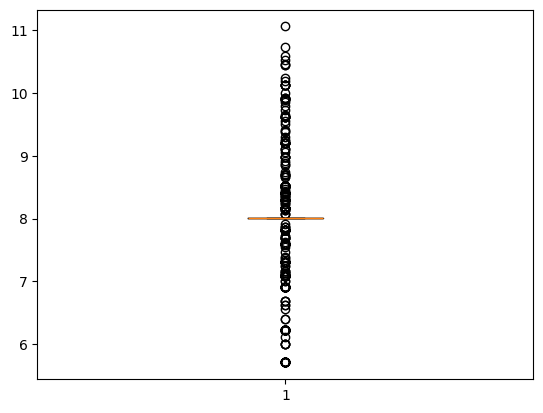

In [ ]:
import matplotlib.pyplot as plt

plt.boxplot(df['Variable_21'].dropna())
plt.show()

**Feature Relationship Analysis**

In [ ]:
corr = df.corr(numeric_only=True, method='pearson')

In [ ]:
corr_spearman = df.corr(numeric_only=True, method='spearman')

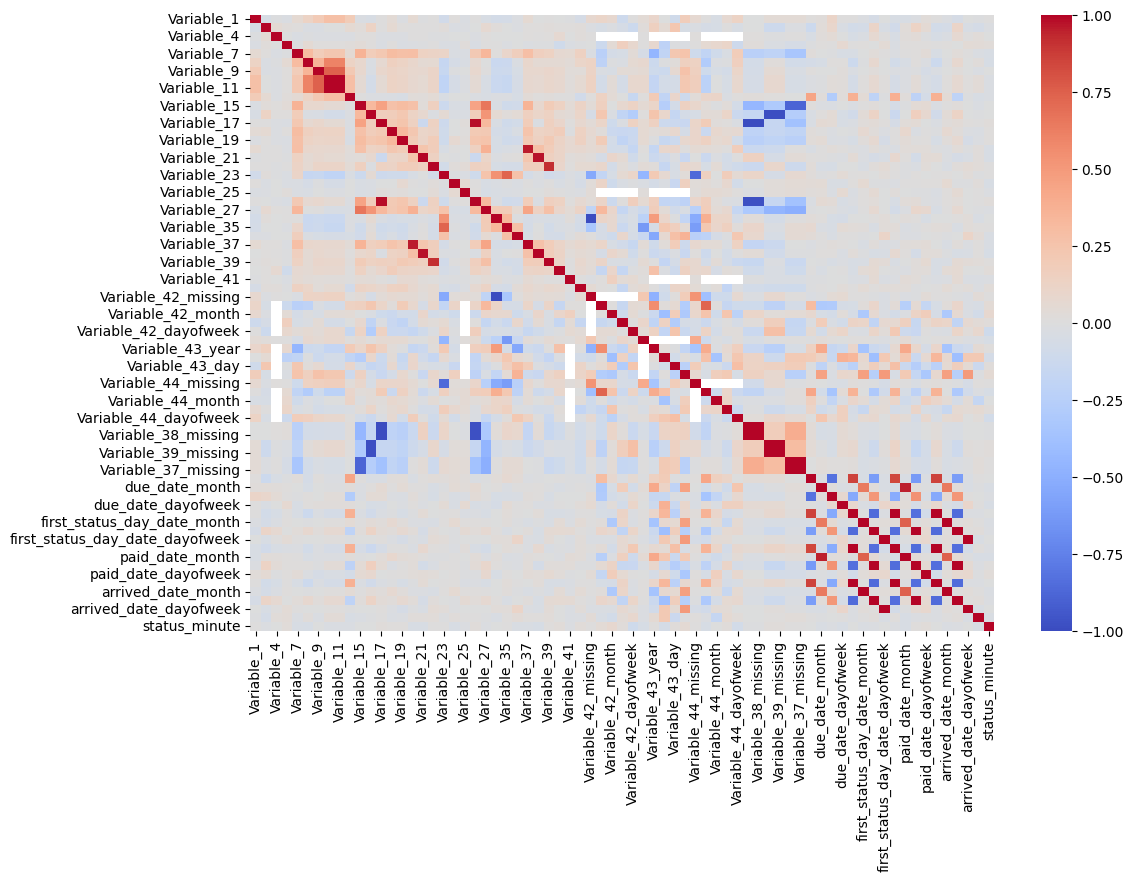

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm')
plt.show()

In [ ]:
df[['Variable_37', 'Variable_21']].corr()

,Variable_37,Variable_21
Variable_37,1.000000,0.239307
Variable_21,0.239307,1.000000


In [ ]:
df[['Variable_27', 'Variable_15']].corr()

,Variable_27,Variable_15
Variable_27,1.00000,0.66241
Variable_15,0.66241,1.00000


In [ ]:
df[['arrived_date_dayofweek', 'first_status_day_date_dayofweek']].corr()


,arrived_date_dayofweek,first_status_day_date_dayofweek
arrived_date_dayofweek,1.0,1.0
first_status_day_date_dayofweek,1.0,1.0


In [ ]:
df[['arrived_date_dayofweek','first_status_day_date_dayofweek']].isna().mean()

,0
arrived_date_dayofweek,0.595257
first_status_day_date_dayofweek,0.595257


In [ ]:
df.drop('arrived_date_dayofweek', axis=1, inplace=True)


In [ ]:
df.columns.to_list()

['Variable_1',
 'Variable_2',
 'Variable_4',
 'Variable_6',
 'Variable_7',
 'Variable_8',
 'Variable_9',
 'Variable_10',
 'Variable_11',
 'Variable_12',
 'Variable_13',
 'Variable_14',
 'Variable_15',
 'Variable_16',
 'Variable_17',
 'Variable_18',
 'Variable_19',
 'Variable_20',
 'Variable_21',
 'Variable_22',
 'Variable_23',
 'Variable_24',
 'Variable_25',
 'Variable_26',
 'Variable_27',
 'Variable_29',
 'Variable_35',
 'Variable_36',
 'Variable_37',
 'Variable_38',
 'Variable_39',
 'Variable_40',
 'Variable_41',
 'Variable_45',
 'Target',
 'Variable_42_missing',
 'Variable_42_year',
 'Variable_42_month',
 'Variable_42_day',
 'Variable_42_dayofweek',
 'Variable_43_missing',
 'Variable_43_year',
 'Variable_43_month',
 'Variable_43_day',
 'Variable_43_dayofweek',
 'Variable_44_missing',
 'Variable_44_year',
 'Variable_44_month',
 'Variable_44_day',
 'Variable_44_dayofweek',
 'Variable_21_missing',
 'Variable_38_missing',
 'Variable_22_missing',
 'Variable_39_missing',
 'Variable_20_mis

**Categorical Analysis**

In [ ]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns

In [ ]:
for col in cat_cols:
    print("Column:", col)
    print("nunique:", df[col].nunique())
    print("top categories:\n", df[col].value_counts().head(5))
    print("-"*50)

Column: Variable_13
nunique: 12
top categories:
 Variable_13
G    447
H    414
I    318
M    312
F    278
Name: count, dtype: int64
--------------------------------------------------
Column: Variable_14
nunique: 12
top categories:
 Variable_14
RATINGSTUFE G    447
RATINGSTUFE H    414
RATINGSTUFE I    318
RATINGSTUFE M    312
RATINGSTUFE F    278
Name: count, dtype: int64
--------------------------------------------------
Column: Variable_45
nunique: 3
top categories:
 Variable_45
M    1657
F     908
?       7
Name: count, dtype: int64
--------------------------------------------------


In [ ]:
for col in cat_cols:
    print(df[col].value_counts(normalize=True).head(10))

Variable_13
G    0.178301
H    0.165138
I    0.126845
M    0.124452
F    0.110890
L    0.064220
E    0.058237
K    0.049860
D    0.045074
B    0.036298
Name: proportion, dtype: float64
Variable_14
RATINGSTUFE G    0.178301
RATINGSTUFE H    0.165138
RATINGSTUFE I    0.126845
RATINGSTUFE M    0.124452
RATINGSTUFE F    0.110890
RATINGSTUFE L    0.064220
RATINGSTUFE E    0.058237
RATINGSTUFE K    0.049860
RATINGSTUFE D    0.045074
RATINGSTUFE B    0.036298
Name: proportion, dtype: float64
Variable_45
M    0.644246
F    0.353033
?    0.002722
Name: proportion, dtype: float64


In [ ]:
for col in cat_cols:
  print(df[col].value_counts(normalize=True))

Variable_13
G    0.178301
H    0.165138
I    0.126845
M    0.124452
F    0.110890
L    0.064220
E    0.058237
K    0.049860
D    0.045074
B    0.036298
C    0.029517
A    0.011169
Name: proportion, dtype: float64
Variable_14
RATINGSTUFE G    0.178301
RATINGSTUFE H    0.165138
RATINGSTUFE I    0.126845
RATINGSTUFE M    0.124452
RATINGSTUFE F    0.110890
RATINGSTUFE L    0.064220
RATINGSTUFE E    0.058237
RATINGSTUFE K    0.049860
RATINGSTUFE D    0.045074
RATINGSTUFE B    0.036298
RATINGSTUFE C    0.029517
RATINGSTUFE A    0.011169
Name: proportion, dtype: float64
Variable_45
M    0.644246
F    0.353033
?    0.002722
Name: proportion, dtype: float64


**Target Rate Analysis**

In [ ]:
df.groupby('Variable_13')['Target'].mean().sort_values(ascending=False)

,Target
Variable_13,
E,0.827586
D,0.808081
F,0.791111
A,0.782609
C,0.740741
B,0.740260
K,0.708738
G,0.700855
I,0.665339


In [ ]:
df.groupby('Variable_45')['Target'].mean().sort_values(ascending=False)


,Target
Variable_45,
F,0.714876
?,0.714286
M,0.679758


In [ ]:
df.groupby('Variable_13')['Target'].agg(
    count='count',
    target_rate='mean'
).sort_values('target_rate', ascending=False)

,count,target_rate
Variable_13,,
E,116,0.827586
D,99,0.808081
F,225,0.791111
A,23,0.782609
C,54,0.740741
B,77,0.740260
K,103,0.708738
G,351,0.700855
I,251,0.665339


**More Feature Engineering**

In [ ]:
df2['due_date'] = pd.to_datetime(df2['due_date'], errors='coerce')
df2['paid_date'] = pd.to_datetime(df2['paid_date'], errors='coerce')
df['days_to_pay'] = (
    df2['paid_date'] - df2['due_date']
).dt.days

In [ ]:
df2['arrived_date'] = pd.to_datetime(df2['arrived_date'], errors='coerce')
df['days_to_arrive'] = (
    df2['arrived_date'] - df2['due_date']
).dt.days

In [ ]:
df2['first_status_day_date'] = pd.to_datetime(df2['first_status_day_date'], errors='coerce')
df['days_status_after_due'] = (
    df2['first_status_day_date'] - df2['due_date']
).dt.days

In [ ]:
df['days_status_after_due']

,days_status_after_due
0,-182.0
1,-32.0
2,-32.0
3,NaN
4,-32.0
5,-335.0
6,-152.0
7,NaN
8,NaN
9,NaN


In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

univariate = pd.DataFrame({
    "mean": df[num_cols].mean(),
    "median": df[num_cols].median(),
    "std": df[num_cols].std(),
    "min": df[num_cols].min(),
    "max": df[num_cols].max(),
    "skew": df[num_cols].skew(),
    "kurtosis": df[num_cols].kurtosis()
})

univariate

,mean,median,std,min,max,skew,kurtosis
Variable_1,3.757147e-15,-0.334754,1.000194e+00,-10.566732,2.403157e+00,-0.393960,13.361190
Variable_2,9.052513e-14,-0.512421,1.000194e+00,-0.512421,2.010080e+00,1.440571,0.076876
Variable_4,3.803981e-19,0.000000,1.363874e-17,0.000000,4.891920e-16,0.000000,0.000000
Variable_6,4.909066e+01,49.000000,2.617614e+01,1.000000,9.900000e+01,0.040863,-1.004850
Variable_7,4.421892e-17,-0.040257,1.000195e+00,-1.858516,2.402650e+00,0.073337,-0.881666
Variable_8,1.932850e+02,199.000000,1.109967e+02,0.000000,5.000000e+02,0.604555,1.407999
Variable_9,-4.696433e-16,-0.075131,1.000194e+00,-2.901030,2.270827e+00,0.000686,0.172838
Variable_10,2.652104e-16,0.115502,1.000194e+00,-2.775076,2.869702e+00,0.024177,0.711016
Variable_11,2.652104e-16,0.115502,1.000194e+00,-2.775076,2.869702e+00,0.024177,0.711016
Variable_12,3.839288e+01,45.000000,2.793255e+01,0.000000,9.900000e+01,0.580324,0.187211


**Validation Design**

In [ ]:
train_df = df[df["Target"].notna()].copy()
test_df = df[df["Target"].isna()].copy()

print("\nTrain shape:", train_df.shape)
print("Test shape:", test_df.shape)



Train shape: (2057, 76)
Test shape: (515, 76)


In [ ]:
X = train_df.drop(columns=["Target"])
y = train_df["Target"].astype(int)

X_test = test_df.drop(columns=["Target"])

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]


In [ ]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
def evaluate(model, name):

    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    cv_auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc").mean()

    pipe.fit(X_train, y_train)

    pred_prob = pipe.predict_proba(X_valid)[:,1]
    pred = pipe.predict(X_valid)

    return {
        "Model": name,
        "CV_AUC": cv_auc,
        "ROC_AUC": roc_auc_score(y_valid, pred_prob),
        "PR_AUC": average_precision_score(y_valid, pred_prob),
        "Accuracy": accuracy_score(y_valid, pred),
        "Precision": precision_score(y_valid, pred),
        "Recall": recall_score(y_valid, pred),
        "F1": f1_score(y_valid, pred),
        "pipeline": pipe
    }

In [ ]:
results = []

# Logistic Regression
results.append(evaluate(LogisticRegression(max_iter=3000), "LogReg"))

# Random Forest
results.append(evaluate(RandomForestClassifier(n_estimators=400, random_state=42), "RF"))

# XGBoost
if XGB_AVAILABLE:
    results.append(evaluate(
        XGBClassifier(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42
        ),
        "XGBoost"
    ))

# CatBoost
if CAT_AVAILABLE:
    results.append(evaluate(
        CatBoostClassifier(
            iterations=400,
            depth=6,
            learning_rate=0.05,
            verbose=0,
            random_seed=42
        ),
        "CatBoost"
    ))

In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("CV_AUC", ascending=False)

print("\nMODEL COMPARISON:\n")
print(results_df.drop(columns=["pipeline"]))


MODEL COMPARISON:

      Model    CV_AUC   ROC_AUC    PR_AUC  Accuracy  Precision    Recall  \
0    LogReg  0.655524  0.675038  0.805522  0.699029   0.724234  0.912281   
3  CatBoost  0.624068  0.658406  0.796706  0.696602   0.717391  0.926316   
1        RF  0.623783  0.674734  0.810600  0.713592   0.722667  0.950877   
2   XGBoost  0.614161  0.648128  0.811754  0.686893   0.729412  0.870175   

         F1  
0  0.807453  
3  0.808576  
1  0.821212  
2  0.793600  


**Hyper Parameter Tunning**

In [ ]:
xg_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", XGBClassifier(random_state=42))
])

param_grid = {
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [6, 8, 10, None],
    "model__min_samples_split": [2, 5, 10]
}

search = RandomizedSearchCV(
    xg_pipe,
    param_grid,
    n_iter=10,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

search.fit(X, y)

print("\nBEST RF PARAMS:", search.best_params_)

In [ ]:
best_model = results_df.iloc[0]["pipeline"]
best_model.fit(X_train, y_train)

In [ ]:
pred_prob = best_model.predict_proba(X_test)[:,1]
pred_class = (pred_prob > 0.5).astype(int)

submission = pd.DataFrame({
    "application_id": test_df["application_id"],
    "predicted_probability": pred_prob,
    "predicted_target": pred_class
})

submission.to_csv("final_predictions.csv", index=False)

print("\nDONE - FILE SAVED: final_predictions.csv")

In [ ]:
# ==============================
# SHAP EXPLANATION (GLOBAL + LOCAL)
# ==============================

import shap

# Fit best model if not already fitted
best_model.fit(X_train, y_train)

# Transform data (because pipeline is used)
X_transformed = best_model.named_steps["prep"].transform(X)

# Get feature names
try:
    ohe = best_model.named_steps["prep"].named_transformers_["cat"].named_steps["encoder"]
    cat_features = ohe.get_feature_names_out(cat_cols)
    feature_names = np.concatenate([num_cols, cat_features])
except:
    feature_names = num_cols

# SHAP Tree Explainer (works best for tree models)
explainer = shap.TreeExplainer(best_model.named_steps["model"])
shap_values = explainer.shap_values(X_transformed)

# Global feature importance
shap.summary_plot(shap_values, X_transformed, feature_names=feature_names)